In [9]:
import pandas as pd
import numpy as np
import xgboost as xgb
import warnings
import sys
warnings.filterwarnings('ignore')
sys.path.append('../..')

from sklearn.metrics import roc_auc_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import TimeSeriesSplit
from src.utils.config import PROCESSED_DIR

In [10]:
X_train = pd.read_csv(PROCESSED_DIR/'splits/AAPL/X_train.csv',
                      index_col=0, parse_dates=True)
y_train = pd.read_csv(PROCESSED_DIR/'splits/AAPL/y_train.csv',
                      index_col=0).squeeze()

print(f'Training rows: {len(X_train)}')
print(f'Features: {X_train.shape[1]}')
print(f'Up days:   {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Down days: {(y_train==0).sum()} ({(1-y_train.mean())*100:.1f}%)')

Training rows: 1762
Features: 43
Up days:   1037 (58.9%)
Down days: 725 (41.1%)


In [11]:
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
weight_dict = dict(zip(classes, weights))
scale_pos_weight = weight_dict[1] / weight_dict[0]

print(f'Class weights: {weight_dict}')
print(f'scale_pos_weight: {scale_pos_weight:.3f}')

Class weights: {0: 1.2151724137931035, 1: 0.849566055930569}
scale_pos_weight: 0.699


In [12]:
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []
cv_details = []

print('Running 5-Fold Time Series Cross Validation...')
print('=' * 55)

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):

    # Split this fold
    X_tr = X_train.iloc[tr_idx]
    y_tr = y_train.iloc[tr_idx]
    X_v  = X_train.iloc[val_idx]
    y_v  = y_train.iloc[val_idx]

    # Train model
    m = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc',
        random_state=42
    )
    m.fit(X_tr, y_tr, verbose=False)

    # Evaluate
    proba = m.predict_proba(X_v)[:, 1]
    score = roc_auc_score(y_v, proba)
    cv_scores.append(score)

    print(f'Fold {fold+1}:  AUC = {score:.4f}  '
          f'| rows = {len(X_v)}  '
          f'| up% = {y_v.mean()*100:.0f}%')

print('=' * 55)
print(f'Mean AUC : {np.mean(cv_scores):.4f}')
print(f'Std  AUC : {np.std(cv_scores):.4f}')
print(f'Min  AUC : {np.min(cv_scores):.4f}')
print(f'Max  AUC : {np.max(cv_scores):.4f}')

Running 5-Fold Time Series Cross Validation...
Fold 1:  AUC = 0.5218  | rows = 293  | up% = 61%
Fold 2:  AUC = 0.4662  | rows = 293  | up% = 60%
Fold 3:  AUC = 0.5001  | rows = 293  | up% = 72%
Fold 4:  AUC = 0.5066  | rows = 293  | up% = 57%
Fold 5:  AUC = 0.5423  | rows = 293  | up% = 45%
Mean AUC : 0.5074
Std  AUC : 0.0252
Min  AUC : 0.4662
Max  AUC : 0.5423


In [13]:
final_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42
)
final_model.fit(X_train, y_train, verbose=False)
print('Final model trained on full training set!')

Final model trained on full training set!


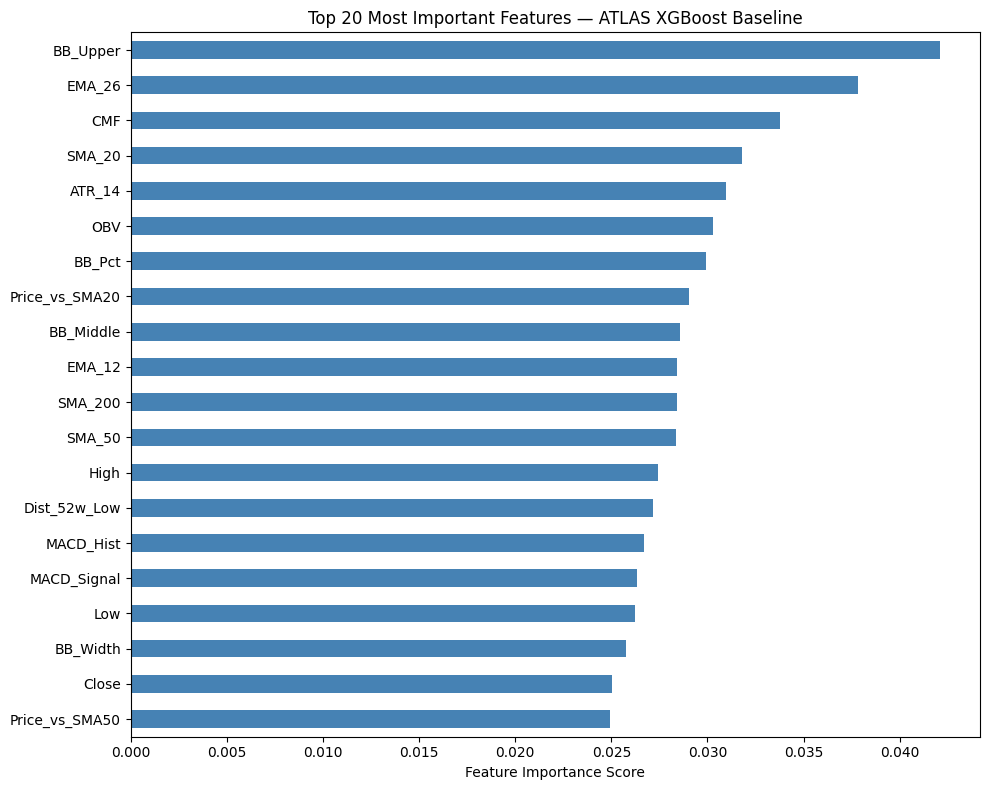


Top 5 features:
BB_Upper    0.042075
EMA_26      0.037813
CMF         0.033774
SMA_20      0.031808
ATR_14      0.030983
dtype: float32


In [14]:
import matplotlib.pyplot as plt

importance = pd.Series(
    final_model.feature_importances_,
    index=X_train.columns
)
top20 = importance.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Most Important Features — ATLAS XGBoost Baseline')
ax.set_xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('../../docs/feature_importance.png')
plt.show()

print(f'\nTop 5 features:')
print(top20.head())